# 01 — Tic-Tac-Toe: Minimax y MCTS

**Obligatorio 2 — Sistemas Multiagente**

Tic-Tac-Toe es un juego de **información perfecta**, 2 jugadores, suma cero y
totalmente resoluble. Lo usamos para validar los agentes de búsqueda:

- **Minimax** (provisto) — búsqueda exhaustiva hasta una profundidad dada. Cuando
  no llega a un estado terminal usa la **función de evaluación** `game.eval()`.
- **MCTS** (implementado) — Monte Carlo Tree Search con selección UCB1 y *rollouts*
  aleatorios.

En este notebook variamos: **profundidad** de minimax, **simulaciones** y
**rollouts** de MCTS, y la **posición** (jugar primero o segundo). Medimos
*tasa de victoria/empate/derrota* y *tiempo de ejecución*.

> Recompensas: `+1` gana, `0` empata, `-1` pierde.

In [1]:
import sys, os
try:
    ROOT = os.path.dirname(__vsc_ipynb_file__)   # VS Code
except NameError:
    ROOT = os.getcwd()                            # Jupyter / fallback
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print("Raiz del proyecto:", ROOT)

Raiz del proyecto: C:\Users\joaco\Documents\ort\semestre_3\obligatorio2-sma\obligatorio_2_joaco


In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

from games.tictactoe.tictactoe import TicTacToe
from agents.minimax import MiniMax
from agents.mcts import MonteCarloTreeSearch
from agents.agent_random import RandomAgent
from utils import run_games, win_draw_loss, matchup_both_sides, run_tournament, plot_tournament_heatmap

np.random.seed(42)
NG = 20   # partidas por posicion (se juegan ambas => 2*NG partidas por punto)
print("Listo. NG =", NG)

Listo. NG = 20


## 1. Minimax: profundidad y función de evaluación

La función de evaluación de Tic-Tac-Toe (`TicTacToe.eval`) cuenta cuántas
líneas (filas, columnas, diagonales) siguen abiertas para cada jugador y
devuelve la diferencia normalizada. Con profundidad limitada, minimax usa esa
heurística en las hojas.

Barremos profundidades `1..4` enfrentando minimax contra un agente **aleatorio**,
jugando ambas posiciones.

> **Nota de costo:** minimax aquí no usa poda alfa-beta y clona el entorno en cada
> nodo, por lo que el costo crece muy rápido. Medimos (1ª jugada desde tablero vacío):
> `d4 ≈ 0.9s`, `d6 ≈ 16s`, `d9 (completo) ≈ 103s`. Una partida a profundidad
> completa contra Random tarda ~76s, por eso acotamos a `d ≤ 4`.

In [3]:
depths = [1, 2, 3]
rows = []
for d in depths:
    res = matchup_both_sides(
        TicTacToe,
        make_a=lambda g, a, d=d: MiniMax(g, a, depth=d),
        make_b=lambda g, a: RandomAgent(g, a),
        n_games=NG,
    )
    rows.append({
        'depth': d,
        'mean_reward': res['mean_reward_A'],
        'win':  (res['as_p0']['win']  + res['as_p1']['win'])  / 2,
        'draw': (res['as_p0']['draw'] + res['as_p1']['draw']) / 2,
        'loss': (res['as_p0']['loss'] + res['as_p1']['loss']) / 2,
        'time_per_game': res['time'] / (2 * NG),
    })
df_mm = pd.DataFrame(rows)
df_mm.round(3)

,depth,mean_reward,win,draw,loss,time_per_game
0,1,0.65,0.80,0.05,0.15,0.004
1,2,0.85,0.85,0.15,0.00,0.018
2,3,0.90,0.90,0.10,0.00,0.170


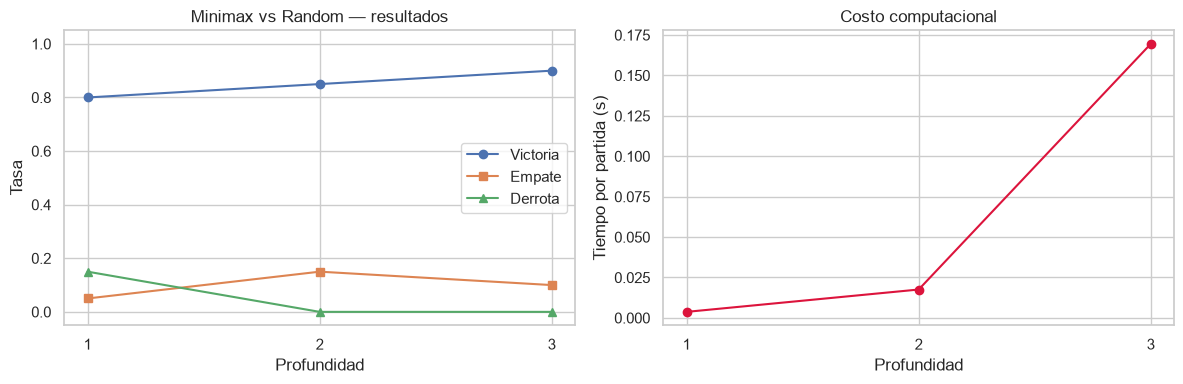

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df_mm.depth, df_mm.win,  'o-', label='Victoria')
ax[0].plot(df_mm.depth, df_mm.draw, 's-', label='Empate')
ax[0].plot(df_mm.depth, df_mm.loss, '^-', label='Derrota')
ax[0].set(xlabel='Profundidad', ylabel='Tasa', title='Minimax vs Random — resultados')
ax[0].set_xticks(depths); ax[0].set_ylim(-0.05, 1.05); ax[0].legend()
ax[1].plot(df_mm.depth, df_mm.time_per_game, 'o-', color='crimson')
ax[1].set(xlabel='Profundidad', ylabel='Tiempo por partida (s)', title='Costo computacional')
ax[1].set_xticks(depths)
plt.tight_layout(); plt.show()

**Observación.** Al aumentar la profundidad, minimax "ve" más jugadas hacia
adelante: la tasa de derrota cae a 0 y crece la de victoria, a costa de un
tiempo por partida que crece de forma marcada. Contra un rival aleatorio incluso
profundidades chicas bastan para no perder casi nunca.

## 2. MCTS: número de simulaciones

Cada decisión de MCTS corre `simulations` iteraciones (selección UCB → expansión
→ *rollout* → *backprop*) y luego juega la acción más visitada. Más simulaciones =
mejor estimación, más tiempo. Fijamos `rollouts=10` y barremos las simulaciones.

In [5]:
sims_list = [10, 25, 50, 100]
rows = []
for s in sims_list:
    res = matchup_both_sides(
        TicTacToe,
        make_a=lambda g, a, s=s: MonteCarloTreeSearch(g, a, simulations=s, rollouts=10),
        make_b=lambda g, a: RandomAgent(g, a),
        n_games=NG,
    )
    rows.append({
        'sims': s,
        'win':  (res['as_p0']['win']  + res['as_p1']['win'])  / 2,
        'draw': (res['as_p0']['draw'] + res['as_p1']['draw']) / 2,
        'loss': (res['as_p0']['loss'] + res['as_p1']['loss']) / 2,
        'time_per_game': res['time'] / (2 * NG),
    })
df_sims = pd.DataFrame(rows)
df_sims.round(3)

,sims,win,draw,loss,time_per_game
0,10,0.875,0.075,0.050,0.112
1,25,0.925,0.050,0.025,0.263
2,50,0.975,0.025,0.000,0.515
3,100,0.950,0.050,0.000,0.819


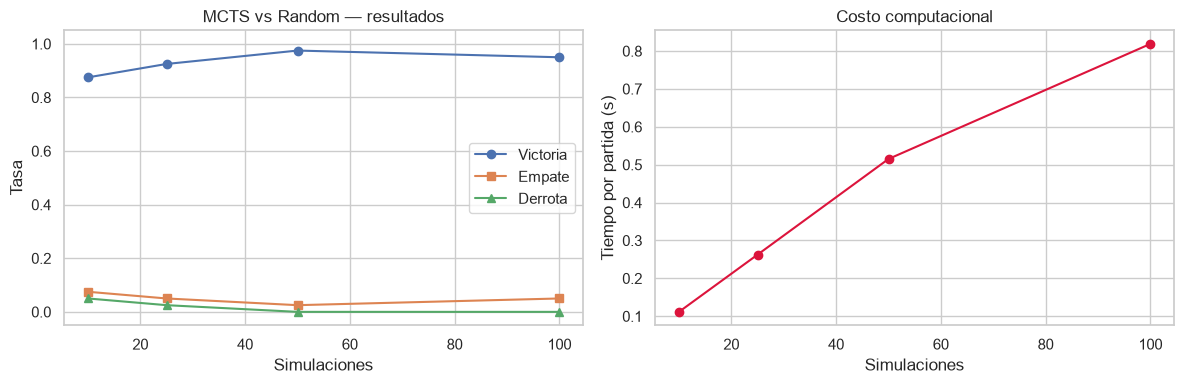

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df_sims.sims, df_sims.win,  'o-', label='Victoria')
ax[0].plot(df_sims.sims, df_sims.draw, 's-', label='Empate')
ax[0].plot(df_sims.sims, df_sims.loss, '^-', label='Derrota')
ax[0].set(xlabel='Simulaciones', ylabel='Tasa', title='MCTS vs Random — resultados')
ax[0].set_ylim(-0.05, 1.05); ax[0].legend()
ax[1].plot(df_sims.sims, df_sims.time_per_game, 'o-', color='crimson')
ax[1].set(xlabel='Simulaciones', ylabel='Tiempo por partida (s)', title='Costo computacional')
plt.tight_layout(); plt.show()

## 3. MCTS: número de *rollouts*

Los *rollouts* promedian varias partidas aleatorias por nodo expandido,
reduciendo la varianza de la estimación. Fijamos `simulations=50` y variamos los
*rollouts*.

In [7]:
rollouts_list = [1, 5, 10, 20]
rows = []
for r in rollouts_list:
    res = matchup_both_sides(
        TicTacToe,
        make_a=lambda g, a, r=r: MonteCarloTreeSearch(g, a, simulations=50, rollouts=r),
        make_b=lambda g, a: RandomAgent(g, a),
        n_games=NG,
    )
    rows.append({
        'rollouts': r,
        'win':  (res['as_p0']['win']  + res['as_p1']['win'])  / 2,
        'draw': (res['as_p0']['draw'] + res['as_p1']['draw']) / 2,
        'loss': (res['as_p0']['loss'] + res['as_p1']['loss']) / 2,
        'time_per_game': res['time'] / (2 * NG),
    })
df_roll = pd.DataFrame(rows)
df_roll.round(3)

,rollouts,win,draw,loss,time_per_game
0,1,0.900,0.100,0.00,0.119
1,5,0.925,0.025,0.05,0.223
2,10,0.925,0.075,0.00,0.422
3,20,0.975,0.025,0.00,0.753


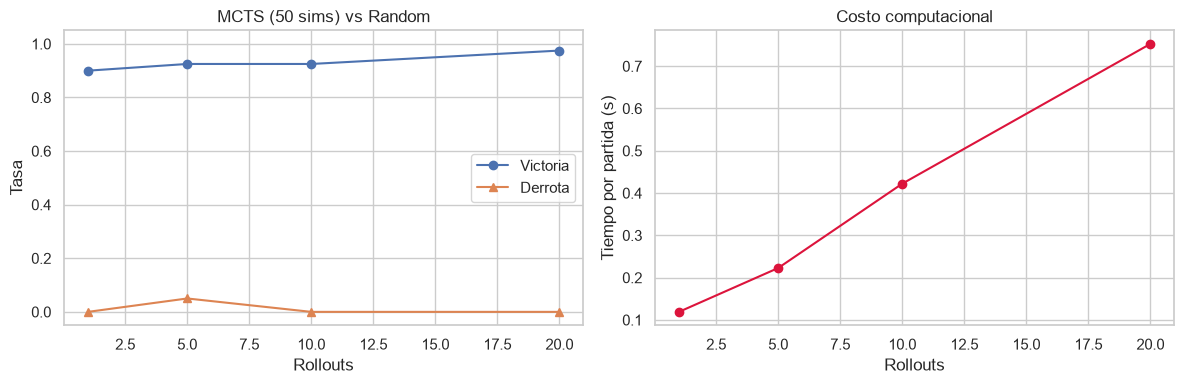

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df_roll.rollouts, df_roll.win,  'o-', label='Victoria')
ax[0].plot(df_roll.rollouts, df_roll.loss, '^-', label='Derrota')
ax[0].set(xlabel='Rollouts', ylabel='Tasa', title='MCTS (50 sims) vs Random'); ax[0].legend(); ax[0].set_ylim(-0.05,1.05)
ax[1].plot(df_roll.rollouts, df_roll.time_per_game, 'o-', color='crimson')
ax[1].set(xlabel='Rollouts', ylabel='Tiempo por partida (s)', title='Costo computacional')
plt.tight_layout(); plt.show()

## 4. Torneo y efecto de la posición

Round-robin entre los tres agentes. `run_tournament` enfrenta cada par en **ambas
posiciones** (cada agente como jugador 0 y como jugador 1); la celda muestra la
recompensa media del agente de la fila contra el de la columna.

  Random vs MCTS(100): -0.950


  Random vs Minimax(d3): -0.850


  MCTS(100) vs Random: 1.000


  MCTS(100) vs Minimax(d3): 0.400


  Minimax(d3) vs Random: 1.000


  Minimax(d3) vs MCTS(100): 0.000


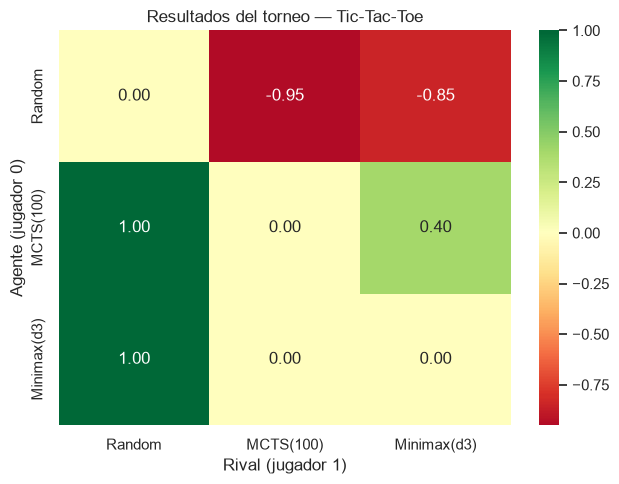

In [9]:
configs = [
    {'name': 'Random',      'class': RandomAgent,            'kwargs': {}},
    {'name': 'MCTS(100)',   'class': MonteCarloTreeSearch,   'kwargs': {'simulations': 100, 'rollouts': 10}},
    {'name': 'Minimax(d3)', 'class': MiniMax,                'kwargs': {'depth': 3}},
]
M = run_tournament(TicTacToe, configs, n_games=20)
fig, ax = plt.subplots(figsize=(6.5, 5))
plot_tournament_heatmap(M, [c['name'] for c in configs], 'Tic-Tac-Toe', ax=ax)
plt.tight_layout(); plt.show()

### Ventaja de jugar primero

Comparamos el desempeño del **mismo** agente como jugador 0 (juega primero) vs
jugador 1, frente a Random.

In [10]:
rows = []
for name, mk in [
    ('MCTS(100)',   lambda g, a: MonteCarloTreeSearch(g, a, simulations=100, rollouts=10)),
    ('Minimax(d3)', lambda g, a: MiniMax(g, a, depth=3)),
]:
    res = matchup_both_sides(TicTacToe, make_a=mk, make_b=lambda g, a: RandomAgent(g, a), n_games=NG)
    rows.append({'agente': name,
                 'win_como_P0': res['as_p0']['win'],
                 'win_como_P1': res['as_p1']['win'],
                 'reward_P0': res['mean_p0'], 'reward_P1': res['mean_p1']})
pd.DataFrame(rows).round(3)

,agente,win_como_P0,win_como_P1,reward_P0,reward_P1
0,MCTS(100),0.95,0.9,0.95,0.9
1,Minimax(d3),1.00,0.9,1.00,0.9


## Conclusiones — Tic-Tac-Toe

- **Minimax** mejora monótonamente con la profundidad y deja de perder con
  profundidades chicas frente a Random, pero su **costo crece de forma explosiva**
  (sin poda y clonando el entorno en cada nodo): la profundidad completa es
  inviable para correr muchas partidas aquí.
- **MCTS** alcanza un desempeño muy alto con pocas simulaciones (el árbol de
  Tic-Tac-Toe es chico) y escala su costo de forma aproximadamente lineal con el
  número de simulaciones. Los *rollouts* aportan poco una vez que hay suficientes
  simulaciones.
- En el **torneo**, MCTS y Minimax dominan a Random y entre sí tienden al
  **empate** (juego óptimo de Tic-Tac-Toe). Jugar **primero** da una ventaja
  medible en la tasa de victoria.